## Access Animal Acoustic Tracking Delayed Detection Qc (Parquet)
This Jupyter notebook demonstrates how to access and plot animal_acoustic_tracking_delayed_detection_qc data, available as a [Parquet](https://parquet.apache.org) dataset stored on S3.

🔗 More information about the dataset is available [in the AODN metadata catalogue](https://catalogue-imos.aodn.org.au/geonetwork/srv/eng/catalog.search#/metadata/541d4f15-122a-443d-ab4e-2b5feb08d6a0).

📌 The source of truth for this notebook is maintained on [GitHub](https://github.com/aodn/aodn_cloud_optimised/tree/main/notebooks/animal_acoustic_tracking_delayed_detection_qc.ipynb).


In [1]:
dataset_name = "animal_acoustic_tracking_delayed_detection_qc"

In [ ]:
# load dataset with pyarrow only 


## Install/Update packages and Load common functions

In [2]:
import os, requests, importlib.util

open('setup.py', 'w').write(requests.get('https://raw.githubusercontent.com/aodn/aodn_cloud_optimised/main/notebooks/setup.py').text)

spec = importlib.util.spec_from_file_location("setup", "setup.py")
setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(setup)

setup.install_requirements()
setup.load_dataquery()

✅ Virtual environment already exists, skipping creation.


Using Python 3.11.0rc1 environment at: /home/ecougnon/github_repo/aodn_cloud_optimised/.venv
Resolved 204 packages in 472ms
Uninstalled 69 packages in 191ms
Installed 69 packages in 114ms
 - aiobotocore==3.7.0
 + aiobotocore==2.26.0
 - aiohappyeyeballs==2.7.1
 + aiohappyeyeballs==2.6.1
 - aiohttp==3.14.1
 + aiohttp==3.13.2
 - anyio==4.14.2
 + anyio==4.12.0
 - attrs==26.1.0
 + attrs==25.4.0
 - bokeh==3.9.1
 + bokeh==3.8.1
 - boto3==1.43.0
 + boto3==1.41.5
 - botocore==1.43.0
 + botocore==1.41.5
 - certifi==2026.6.17
 + certifi==2025.11.12
 - cffi==2.1.0
 + cffi==2.0.0
 - click==8.4.2
 + click==8.3.1
 - coiled==1.135.1
 + coiled==1.130.0
 - cryptography==49.0.0
 + cryptography==46.0.3
 - dask==2026.7.1
 + dask==2025.12.0
 - decorator==5.3.1
 + decorator==5.2.1
 - distributed==2026.7.1
 + distributed==2025.12.0
 - fabric==3.2.3
 + fabric==3.2.2
 - filelock==3.29.7
 + filelock==3.20.1
 - fsspec==2026.6.0
 + fsspec==2025.12.0
 - geopandas==1.1.4
 + geopandas==1.1.1
 - h5netcdf==1.8.1
 + h5n

✅ Local version 0.3.31 is up to date (remote: 0.3.30)


In [3]:
from DataQuery import GetAodn

/home/ecougnon/github_repo/aodn_cloud_optimised/notebooks/DataQuery.py:4865: UserWarning: registration of accessor <class 'DataQuery.AODNAccessor'> under name 'aodn' for type <class 'pandas.core.frame.DataFrame'> is overriding a preexisting attribute with the same name.
  @pd.api.extensions.register_dataframe_accessor("aodn")


# Understanding the Dataset

## Understanding Parquet Partitioning

Parquet files can be **partitioned** by one or more columns, which means the data is physically organised into folders based on the values in those columns. This is similar to how databases use indexes to optimise query performance.

Partitioning enables **faster filtering**: when you query data using a partitioned column, only the relevant subset of files needs to be read—improving performance significantly.

For example, if a dataset is partitioned by `"site_code"`, `"timestamp"`, and `"polygon"`, filtering on `"site_code"` allows the system to skip unrelated files entirely.

In this notebook, the `GetAodn` class includes built-in methods to efficiently filter data by **time** and **latitude/longitude** using the **timestamp** and **polygon** partitions. Other partitions can be used for filtering via the `scalar_filter`.

Any filtering on columns that are **not** partitioned can be significantly slower, as all files may need to be scanned. However, the `GetAodn` class provides a `scalar_filter` method that lets you apply these filters at load time—before the data is fully read—helping reduce the size of the resulting DataFrame.

Once the dataset is loaded, further filtering using Pandas is efficient and flexible.

See further below in the notebook for examples of how to filter the data effectively.

To view the actual partition columns for this dataset, run:


In [4]:
aodn = GetAodn()
dname = f'{dataset_name}.parquet'
%time aodn_dataset = aodn.get_dataset(dname)

CPU times: user 15.7 ms, sys: 2.51 ms, total: 18.2 ms
Wall time: 46.1 ms


In [5]:
aodn_dataset.dataset.partitioning.schema

timestamp: int32
polygon: string

In [6]:
aodn_dataset.get_metadata()

2026-09-28 08:58:02,670 - aodn.GetAodn - INFO - Retrieving metadata for aodn-cloud-optimised/animal_acoustic_tracking_delayed_detection_qc.parquet


{'FDA_QC': {'type': 'int32',
  'units': '',
  'comments': 'detection fails this test (‘FDA_QC’ = 2) if tag detected only once or if there were more long (> 12 hours) than short periods (< 30 minutes) between detections at a given installation. Quality Control Flag Values: ## 0: no qc performed ## 1: good data ## 2: likely invalid data ## 3: missing data',
  'long_name': 'False Detection Algorithm test',
  'standard_name': ''},
 'active': {'type': 'string',
  'units': '',
  'comments': 'True if the transmitter is still active, FALSE if it is inactive',
  'long_name': '',
  'standard_name': ''},
 'tag_id': {'type': 'int32',
  'units': '',
  'comments': 'unique tag identifier in the IMOS Animal Tracking Acoustic Telemetry Database',
  'long_name': '',
  'standard_name': ''},
 'polygon': {'type': 'string',
  'units': '1',
  'long_name': 'Spatial partition polygon'},
 'filename': {'type': 'string',
  'units': '1',
  'long_name': 'Filename of the source file'},
 'placement': {'type': 'string

In [7]:
aodn_dataset.describe()

{'format': 'parquet',
 'dataset_name': 'aodn-cloud-optimised/animal_acoustic_tracking_delayed_detection_qc.parquet',
 'n_columns': 58,
 'columns': {'FDA_QC': {'dtype': 'int32'},
  'active': {'dtype': 'string'},
  'tag_id': {'dtype': 'int32'},
  'filename': {'dtype': 'string'},
  'placement': {'dtype': 'string'},
  'animal_sex': {'dtype': 'string'},
  'Distance_QC': {'dtype': 'int32'},
  'Velocity_QC': {'dtype': 'int32'},
  'measurement': {'dtype': 'string'},
  'receiver_id': {'dtype': 'int32'},
  'Detection_QC': {'dtype': 'int32'},
  'station_name': {'dtype': 'string'},
  'receiver_name': {'dtype': 'string'},
  'ReleaseDate_QC': {'dtype': 'int32'},
  'receiver_depth': {'dtype': 'double'},
  'transmitter_id': {'dtype': 'string'},
  'CAAB_species_id': {'dtype': 'int32'},
  'receiver_status': {'dtype': 'string'},
  'transmitter_type': {'dtype': 'string'},
  'installation_name': {'dtype': 'string'},
  'DistanceRelease_QC': {'dtype': 'int32'},
  'ReleaseLocation_QC': {'dtype': 'int32'},
  '

In [17]:
import pyarrow.parquet as pq
import s3fs

fname = "s3://aodn-cloud-optimised/animal_acoustic_tracking_delayed_detection_qc.parquet"

fs = s3fs.S3FileSystem(anon=True)
schema = pq.read_schema(fname)
#table = pq.read_table(fname, filesystem=fs)
#df = table.to_pandas()

OSError: When reading information for key 'animal_acoustic_tracking_delayed_detection_qc.parquet' in bucket 'aodn-cloud-optimised': AWS Error ACCESS_DENIED during HeadObject operation: No response body.

In [14]:
dname

'animal_acoustic_tracking_delayed_detection_qc.parquet'

## List unique partition values

In [ ]:
%%time
unique_partition_value = aodn_dataset.get_unique_partition_values('YOUR_PARTITION_KEY')
print(list(unique_partition_value)[0:2])  # showing a subset only

## Visualise Spatial Extent of the dataset
This section plots the polygons representing the areas where data is available. It helps to identify and create a bounding box around the regions containing data.

/home/ecougnon/anaconda3/envs/AodnCloudOptimised/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


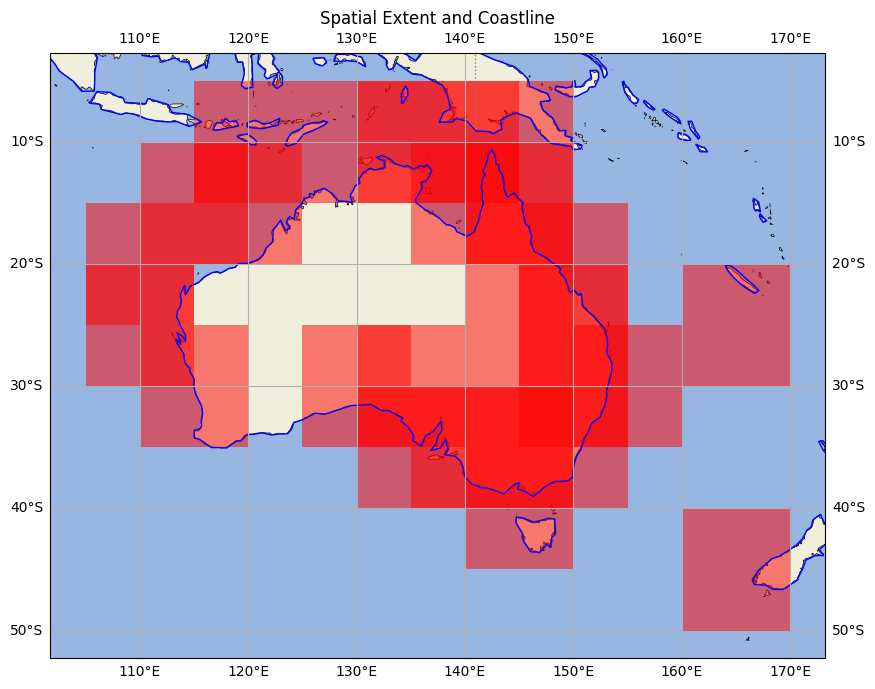

In [8]:
aodn_dataset.plot_spatial_extent()

## Get Temporal Extent of the dataset

Similarly to the spatial extent, we're retrieving the minimum and maximum timestamp partition values of the dataset. This is not necessarily an accurate representation of the TIME values, as the timestamp partition can be yearly/monthly... but is here to give an idea

In [8]:
%%time
aodn_dataset.get_temporal_extent()

CPU times: user 137 ms, sys: 8.37 ms, total: 145 ms
Wall time: 315 ms


(Timestamp('2007-08-08 07:15:28'), Timestamp('2026-12-05 22:43:00'))

In [13]:
aodn_dataset.get_temporal_extent()[0]

Timestamp('2007-08-08 07:15:28')

In [9]:
## get data
# takes too long, large dataset 
#df = aodn_dataset.get_data(date_start=aodn_dataset.get_temporal_extent()[0].strftime('%Y-%m-%d'), 
#                           date_end=aodn_dataset.get_temporal_extent()[1].strftime('%Y-%m-%d'),
#                           )
df = aodn_dataset.get_data(date_start="2026-07-01", date_end="2026-12-31")

2026-09-24 15:08:48,092 - aodn.GetAodn - INFO - Retrieving metadata for aodn-cloud-optimised/animal_acoustic_tracking_delayed_detection_qc.parquet


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 58 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   FDA_QC                              11 non-null     int32         
 1   active                              11 non-null     object        
 2   tag_id                              11 non-null     int32         
 3   filename                            11 non-null     object        
 4   placement                           11 non-null     object        
 5   animal_sex                          11 non-null     object        
 6   Distance_QC                         11 non-null     int32         
 7   Velocity_QC                         11 non-null     int32         
 8   measurement                         11 non-null     object        
 9   receiver_id                         11 non-null     int32         
 10  Detection_QC                

In [12]:
df["filename"].unique()

array(['IMOS_ATF-ACOUSTIC_TAGID_A69-9001-41284_431156727_431156729.csv',
       'IMOS_ATF-ACOUSTIC_TAGID_A69-9001-59777_259245163_259245165.csv',
       'IMOS_ATF-ACOUSTIC_TAGID_A69-9001-41287_431156793_431156795.csv'],
      dtype=object)

## Read Metadata

For all Parquet datasets, we create a sidecar file named **_common_metadata** in the root of the dataset. This file contains both the dataset-level and variable-level attributes.  
The metadata can be retrieved below as a dictionary, and it will also be included in the pandas DataFrame when using the `get_data` method from the `GetAodn` class.

In [9]:
metadata = aodn_dataset.get_metadata()
metadata

{'FDA_QC': {'type': 'int32',
  'units': '',
  'comments': 'detection fails this test (‘FDA_QC’ = 2) if tag detected only once or if there were more long (> 12 hours) than short periods (< 30 minutes) between detections at a given installation. Quality Control Flag Values: ## 0: no qc performed ## 1: good data ## 2: likely invalid data ## 3: missing data',
  'long_name': 'False Detection Algorithm test',
  'standard_name': ''},
 'active': {'type': 'string',
  'units': '',
  'comments': 'True if the transmitter is still active, FALSE if it is inactive',
  'long_name': '',
  'standard_name': ''},
 'tag_id': {'type': 'int32',
  'units': '',
  'comments': 'unique tag identifier in the IMOS Animal Tracking Acoustic Telemetry Database',
  'long_name': '',
  'standard_name': ''},
 'polygon': {'type': 'string',
  'units': '1',
  'long_name': 'Spatial partition polygon'},
 'filename': {'type': 'string',
  'units': '1',
  'long_name': 'Filename of the source file'},
 'placement': {'type': 'string

# Data Query and Plot

## Create a TIME and BoundingBox filter

This cell loads a subset of the dataset based on a time range and a spatial bounding box. The result is returned as a pandas DataFrame, and basic information about its structure is displayed.

In [ ]:
%%time
df = aodn_dataset.get_data(date_start='2022-12-01', 
                           date_end='2023-01-01',
                           lat_min=-34, 
                           lat_max=-28, 
                           lon_min=151, 
                           lon_max=160, 
                           )

df.info()

In [ ]:
## Download Subsetted Data as CSV

# This cell downloads the filtered dataset as a ZIP-compressed CSV file.  
# The CSV includes metadata at the top as commented lines, and a `FileLink` object is returned to allow downloading directly from the notebook.


df.aodn.download_as_csv()

## Create a TIME and scalar/number filter

This cell filters the dataset by time range and a scalar value (from a Parquet partition) using the `scalar_filter` argument.  
This leverages Parquet partitioning to apply efficient, server-side filtering, which significantly speeds up data loading.

In [ ]:
%%time
df = aodn_dataset.get_data(date_start='2006-07-12', 
                           date_end='2023-02-05',
                           scalar_filter={'YOUR_PARTITION_KEY': 1901740})
df.info()